# Movie Poster Genre Classification

This notebook trains a **multi-label classifier** to predict movie genres from poster images using a fine-tuned **ResNet50** model.

## Features:
- **Class balancing** with positive weights for rare genres
- **Live training feedback** with progress bars and dynamic plots
- **Interactive demo** to test on any image URL

## Cell 1: Imports & Setup

In [1]:
# Standard libraries
import os
import torch
import torch.nn as nn
from torch.optim import Adam
from torchvision import models, transforms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
from tqdm.notebook import tqdm
from IPython.display import display, clear_output

# Custom dataset module
from dataset import get_dataloaders, MoviePosterDataset, IMAGENET_MEAN, IMAGENET_STD

# Constants
BATCH_SIZE = 32
LR = 1e-4
EPOCHS = 10
MODEL_SAVE_PATH = "best_model.pth"

# Device setup
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using CUDA GPU: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS GPU")
else:
    device = torch.device("cpu")
    print("No GPU available, using CPU (training will be slow)")

print(f"\nPyTorch version: {torch.__version__}")

Using CUDA GPU: NVIDIA GeForce RTX 4070 Ti SUPER

PyTorch version: 2.6.0+cu124


## Cell 2: Data Loading & Class Balancing

### Why Class Balancing?
Movie genres are **imbalanced** – Drama and Comedy are very common, while Western and Film-Noir are rare.

We calculate **positive weights** for each class:
$$\text{pos\_weight}_i = \frac{\text{Total Samples} - \text{Positive}_i}{\text{Positive}_i}$$

This makes the model pay more attention to rare genres.

In [2]:
# Load dataloaders
train_loader, val_loader, all_classes = get_dataloaders(
    batch_size=BATCH_SIZE,
    val_split=0.2,
    num_workers=4
)

num_classes = len(all_classes)
print(f"\nDataset loaded:")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Number of genres: {num_classes}")

Loaded 29364 samples from data/MovieGenre_clean.csv
Number of classes: 28
Classes: ['Action', 'Adult', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'Game-Show', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News', 'Reality-TV', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Talk-Show', 'Thriller', 'War', 'Western']

Dataset loaded:
Training batches: 735
Validation batches: 184
Number of genres: 28


Calculating class weights...

Genre Distribution:


,Genre,Count,Percentage,Weight
8,Drama,14965,51.0,0.960000
5,Comedy,9384,32.0,2.130000
20,Romance,4670,15.9,5.290000
0,Action,4026,13.7,6.290000
6,Crime,3865,13.2,6.600000
25,Thriller,3669,12.5,7.000000
7,Documentary,3028,10.3,8.700000
14,Horror,2987,10.2,8.830000
2,Adventure,2887,9.8,9.170000
17,Mystery,1724,5.9,16.030001


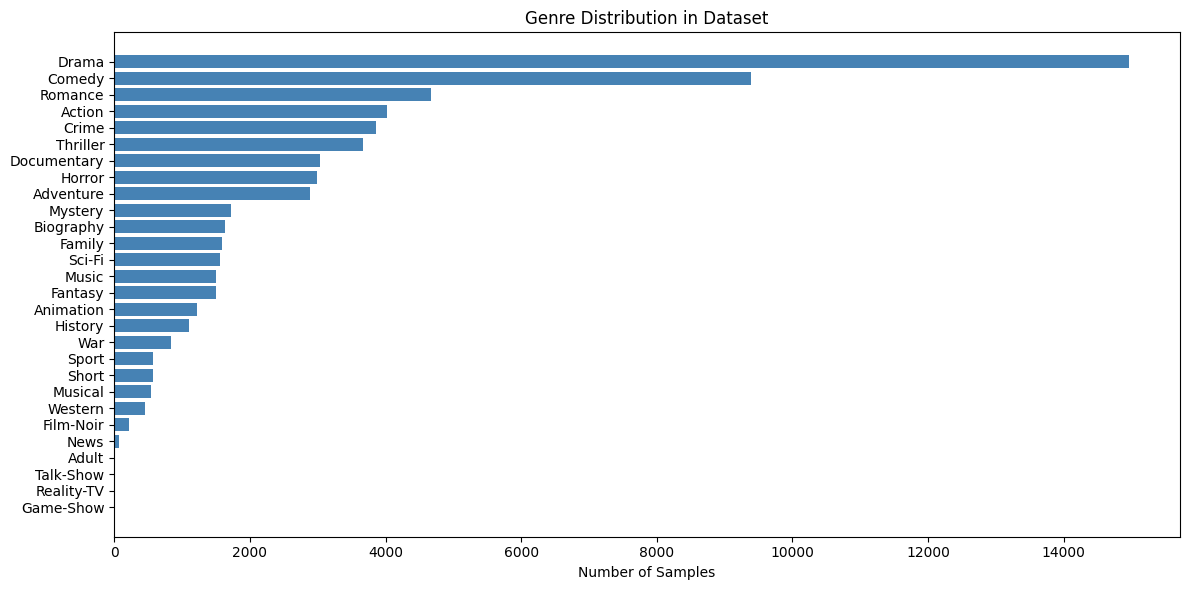

In [3]:
# Calculate class weights for imbalanced data
print("Calculating class weights...")

# Load the cleaned CSV to count class frequencies
df = pd.read_csv("data/MovieGenre_clean.csv")
total_samples = len(df)

# Count positive samples for each genre
class_counts = []
for genre in all_classes:
    count = df["Genre"].str.contains(genre, na=False, regex=False).sum()
    class_counts.append(count)

class_counts = np.array(class_counts)

# Calculate pos_weight: (total - positive) / positive
# Add small epsilon to avoid division by zero
pos_weight = (total_samples - class_counts) / (class_counts + 1e-6)
pos_weight = torch.tensor(pos_weight, dtype=torch.float32)

# Display class distribution
print("\nGenre Distribution:")
genre_df = pd.DataFrame({
    "Genre": all_classes,
    "Count": class_counts,
    "Percentage": (class_counts / total_samples * 100).round(1),
    "Weight": pos_weight.numpy().round(2)
}).sort_values("Count", ascending=False)

display(genre_df)

# Visualize class distribution
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(genre_df["Genre"], genre_df["Count"], color="steelblue")
ax.set_xlabel("Number of Samples")
ax.set_title("Genre Distribution in Dataset")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Cell 3: Model Definition

We use a pretrained **ResNet50** model with:
- Frozen backbone (only train the final layer)
- Custom classification head for our 28 genres

In [4]:
def create_model(num_classes, freeze_backbone=True):
    """
    Create ResNet50 model with modified head for multi-label classification.
    """
    # Load pretrained ResNet50
    model = models.resnet50(weights="DEFAULT")
    
    # Freeze backbone layers
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    
    # Replace the final FC layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    
    # Ensure FC layer is trainable
    for param in model.fc.parameters():
        param.requires_grad = True
    
    return model

# Initialize model
model = create_model(num_classes, freeze_backbone=True)
model = model.to(device)

# Count parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"\nModel created:")
print(f"Trainable parameters: {trainable:,} / {total:,}")
print(f"Model moved to: {device}")


Model created:
Trainable parameters: 57,372 / 23,565,404
Model moved to: cuda


## Cell 4: Training Loop with Live Feedback

Training features:
- **BCEWithLogitsLoss** with positive weights for class balancing
- **Adam optimizer** with learning rate 1e-4
- **Live progress bars** using tqdm.notebook
- **Dynamic loss plot** updated each epoch

In [5]:
def calculate_accuracy(outputs, targets, threshold=0.5):
    """Calculate multi-label accuracy."""
    probs = torch.sigmoid(outputs)
    preds = (probs > threshold).float()
    correct = (preds == targets).float()
    return correct.mean().item()


def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    num_batches = 0
    
    pbar = tqdm(train_loader, desc="Training", leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        acc = calculate_accuracy(outputs, labels)
        total_loss += loss.item()
        total_acc += acc
        num_batches += 1
        
        pbar.set_postfix({"loss": f"{loss.item():.4f}", "acc": f"{acc:.4f}"})
    
    return total_loss / num_batches, total_acc / num_batches


def validate_epoch(model, val_loader, criterion, device):
    """Validate for one epoch."""
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    num_batches = 0
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc="Validation", leave=False)
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            acc = calculate_accuracy(outputs, labels)
            total_loss += loss.item()
            total_acc += acc
            num_batches += 1
            
            pbar.set_postfix({"loss": f"{loss.item():.4f}", "acc": f"{acc:.4f}"})
    
    return total_loss / num_batches, total_acc / num_batches

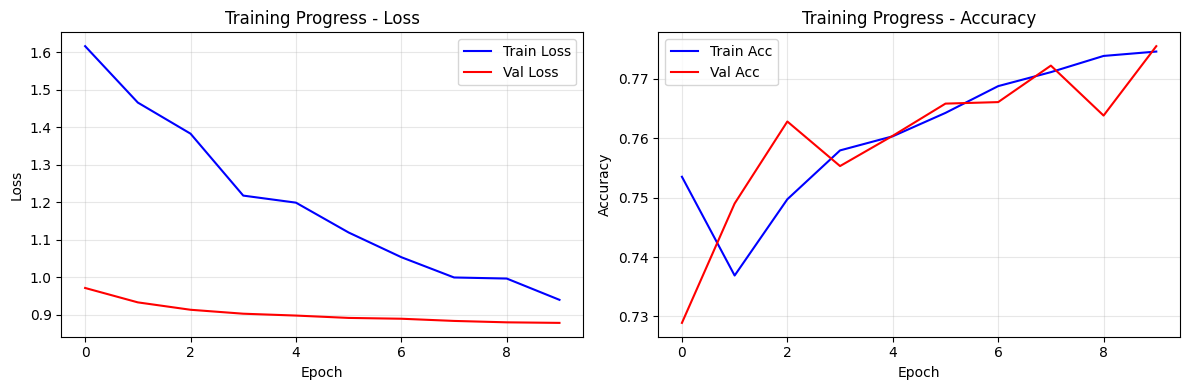

Epoch 10/10: Train Loss=0.9396, Train Acc=0.7746 | Val Loss=0.8782, Val Acc=0.7755 ✓ saved

Training complete! Best validation accuracy: 0.7755
Model saved to: best_model.pth


In [6]:
# Setup training
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
optimizer = Adam(model.parameters(), lr=LR)

# Training history
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0

print(f"\nStarting training for {EPOCHS} epochs...")
print(f"Using class-balanced loss with pos_weight\n")

# Training loop with live plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for epoch in range(EPOCHS):
    # Train and validate
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    # Store history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc": val_acc,
            "all_classes": all_classes,
            "pos_weight": pos_weight,
        }, MODEL_SAVE_PATH)
        saved_marker = " ✓ saved"
    else:
        saved_marker = ""
    
    # Update live plot
    clear_output(wait=True)
    
    axes[0].clear()
    axes[0].plot(train_losses, 'b-', label='Train Loss')
    axes[0].plot(val_losses, 'r-', label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Progress - Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].clear()
    axes[1].plot(train_accs, 'b-', label='Train Acc')
    axes[1].plot(val_accs, 'r-', label='Val Acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training Progress - Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    display(fig)
    
    print(f"Epoch {epoch+1}/{EPOCHS}: "
          f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f} | "
          f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}{saved_marker}")

print(f"\nTraining complete! Best validation accuracy: {best_val_acc:.4f}")
print(f"Model saved to: {MODEL_SAVE_PATH}")
plt.close(fig)

## Cell 5: Evaluation & Visualization

Let's visualize the training curves and see how the model performs on validation samples.

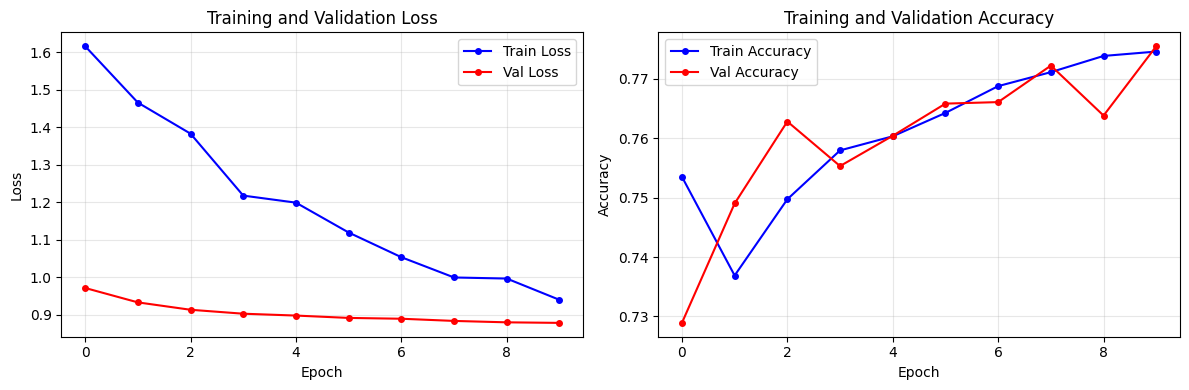

Saved training curves to training_history.png


In [7]:
# Final training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, 'b-o', label='Train Loss', markersize=4)
ax1.plot(val_losses, 'r-o', label='Val Loss', markersize=4)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, 'b-o', label='Train Accuracy', markersize=4)
ax2.plot(val_accs, 'r-o', label='Val Accuracy', markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()
print("Saved training curves to training_history.png")

Loaded best model (val_acc: 0.7755)


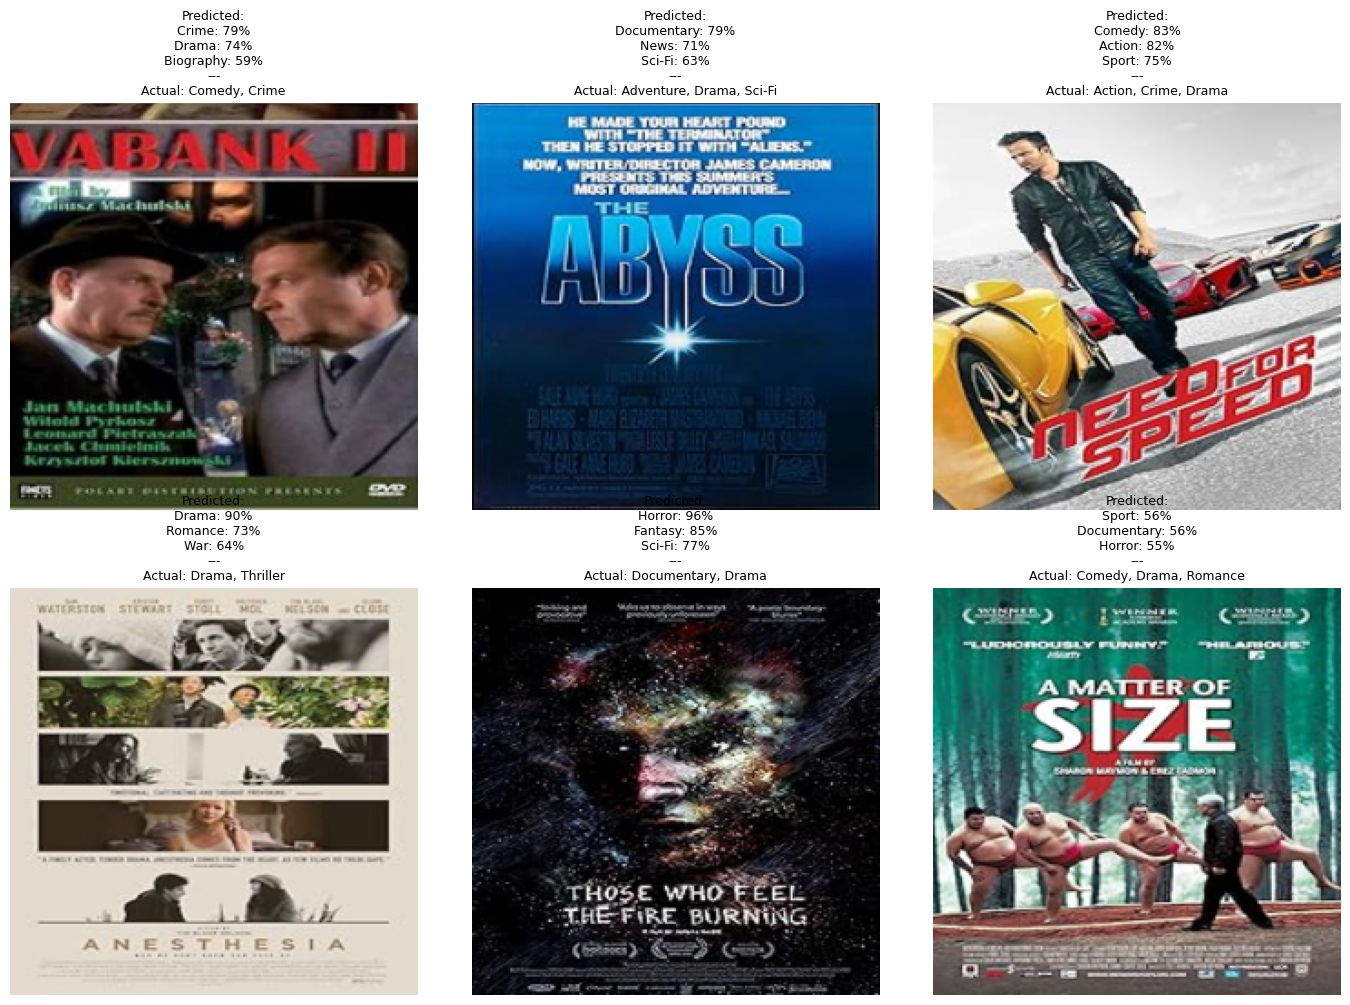

Saved predictions to predictions_grid.png


In [8]:
# Load best model and visualize predictions
checkpoint = torch.load(MODEL_SAVE_PATH, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Loaded best model (val_acc: {checkpoint['val_acc']:.4f})")

# Get a batch of validation images
val_images, val_labels = next(iter(val_loader))

# Predict
with torch.no_grad():
    outputs = model(val_images.to(device))
    probs = torch.sigmoid(outputs).cpu()

# Denormalize for display
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return tensor * std + mean

# Display predictions
n_display = 6
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

for idx in range(n_display):
    # Get image
    img = denormalize(val_images[idx]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    
    # Get predictions
    pred_indices = (probs[idx] > 0.5).nonzero().squeeze(-1).tolist()
    if isinstance(pred_indices, int):
        pred_indices = [pred_indices]
    pred_genres = [(all_classes[i], probs[idx][i].item()) for i in pred_indices]
    pred_genres.sort(key=lambda x: x[1], reverse=True)
    
    # Get actual genres
    actual_indices = val_labels[idx].nonzero().squeeze(-1).tolist()
    if isinstance(actual_indices, int):
        actual_indices = [actual_indices]
    actual_genres = [all_classes[i] for i in actual_indices]
    
    # Display
    axes[idx].imshow(img)
    axes[idx].axis('off')
    
    pred_text = "\n".join([f"{g}: {p*100:.0f}%" for g, p in pred_genres[:3]]) if pred_genres else "None"
    actual_text = ", ".join(actual_genres) if actual_genres else "None"
    
    axes[idx].set_title(f"Predicted:\n{pred_text}\n---\nActual: {actual_text}", fontsize=9)

plt.tight_layout()
plt.savefig('predictions_grid.png', dpi=150)
plt.show()
print("Saved predictions to predictions_grid.png")

## Cell 6: Interactive Demo 

Test the model on any movie poster image! Paste an image URL below.

In [9]:
def predict_from_url(url, model, all_classes, threshold=0.3):
    """
    Predict genres from an image URL.
    """
    # Download image
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        image = Image.open(BytesIO(response.content)).convert("RGB")
    except Exception as e:
        print(f"Error loading image: {e}")
        return None
    
    # Transform
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probs = torch.sigmoid(outputs).cpu().numpy()[0]
    
    # Get predictions above threshold
    predictions = []
    for idx, prob in enumerate(probs):
        if prob > threshold:
            predictions.append((all_classes[idx], prob))
    predictions.sort(key=lambda x: x[1], reverse=True)
    
    # Display results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Show image
    ax1.imshow(image)
    ax1.axis('off')
    ax1.set_title("Input Poster", fontsize=14)
    
    # Show predictions as bar chart
    if predictions:
        genres = [p[0] for p in predictions[:10]]
        scores = [p[1] * 100 for p in predictions[:10]]
        colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(genres)))
        
        ax2.barh(genres, scores, color=colors)
        ax2.set_xlim(0, 100)
        ax2.set_xlabel("Confidence (%)")
        ax2.set_title("Predicted Genres", fontsize=14)
        ax2.invert_yaxis()
        
        for i, (g, s) in enumerate(zip(genres, scores)):
            ax2.text(s + 1, i, f"{s:.1f}%", va='center', fontsize=10)
    else:
        ax2.text(0.5, 0.5, "No genres predicted\nabove threshold", 
                 ha='center', va='center', fontsize=14, transform=ax2.transAxes)
        ax2.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return predictions


print("Interactive Genre Predictor Ready!")
print("Paste a movie poster URL below to test the model.\n")

Interactive Genre Predictor Ready!
Paste a movie poster URL below to test the model.



Testing with: https://m.media-amazon.com/images/M/MV5BMTMxNTMwODM0NF5BMl5BanBnXkFtZTcwODAyMTk2Mw@@._V1_.jpg



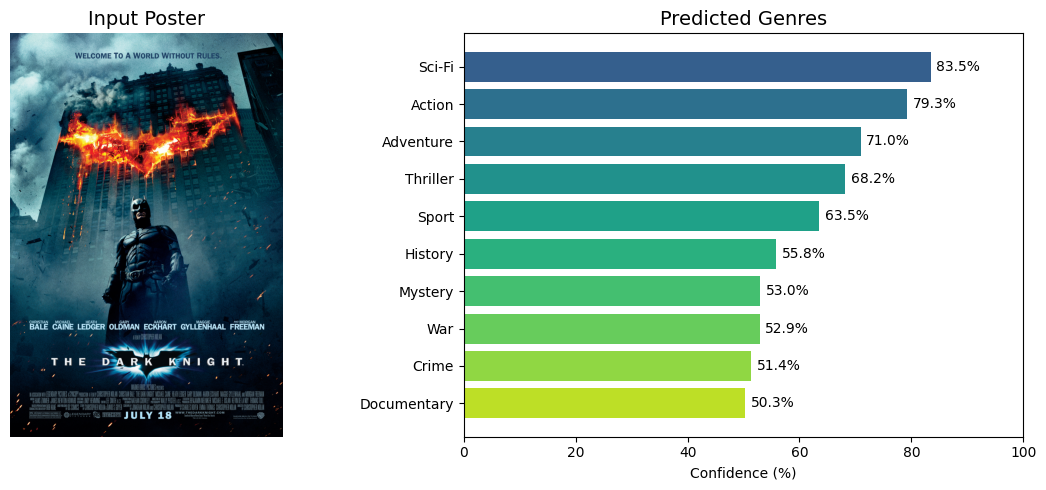


Predicted Genres:
   • Sci-Fi: 83.5%
   • Action: 79.3%
   • Adventure: 71.0%
   • Thriller: 68.2%
   • Sport: 63.5%
   • History: 55.8%
   • Mystery: 53.0%
   • War: 52.9%
   • Crime: 51.4%
   • Documentary: 50.3%
   • Biography: 49.4%
   • Drama: 49.2%
   • Fantasy: 47.7%
   • News: 47.7%
   • Animation: 42.8%
   • Horror: 40.1%
   • Family: 38.6%


In [10]:
# Example: Try with a movie poster URL
# Replace this URL with any movie poster you want to test!

example_url = "https://m.media-amazon.com/images/M/MV5BMTMxNTMwODM0NF5BMl5BanBnXkFtZTcwODAyMTk2Mw@@._V1_.jpg"  # The Dark Knight

print(f"Testing with: {example_url}\n")
predictions = predict_from_url(example_url, model, all_classes)

if predictions:
    print("\nPredicted Genres:")
    for genre, prob in predictions:
        print(f"   • {genre}: {prob*100:.1f}%")

Enter a movie poster URL to test:


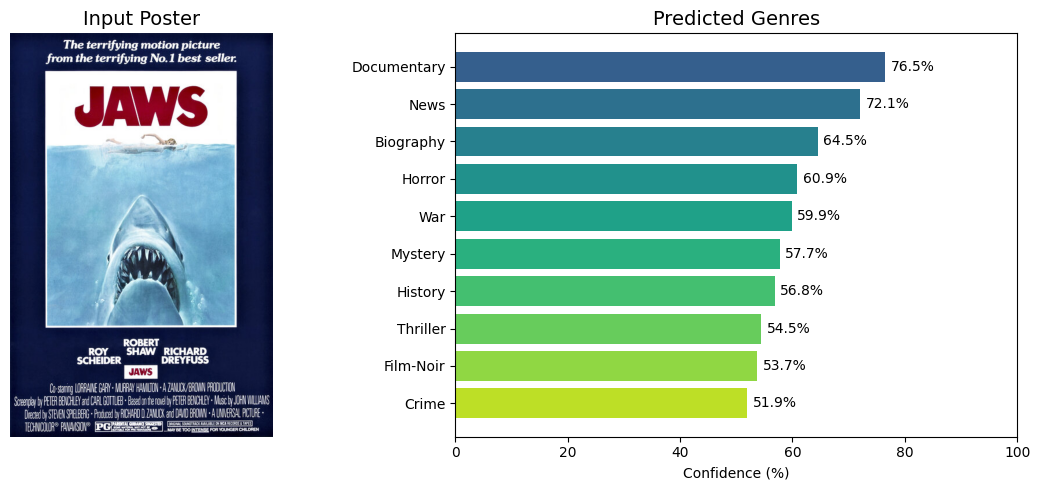


Predicted Genres:
   • Documentary: 76.5%
   • News: 72.1%
   • Biography: 64.5%
   • Horror: 60.9%
   • War: 59.9%
   • Mystery: 57.7%
   • History: 56.8%
   • Thriller: 54.5%
   • Film-Noir: 53.7%
   • Crime: 51.9%
   • Talk-Show: 49.4%
   • Sport: 48.6%
   • Short: 45.6%
   • Drama: 43.6%
   • Musical: 42.1%
   • Sci-Fi: 39.9%
   • Music: 34.2%
   • Comedy: 31.8%
   • Western: 30.6%


In [14]:
# Interactive input - paste your own URL!
print("Enter a movie poster URL to test:")
user_url = input("URL: ").strip()

if user_url:
    predictions = predict_from_url(user_url, model, all_classes)
    if predictions:
        print("\nPredicted Genres:")
        for genre, prob in predictions:
            print(f"   • {genre}: {prob*100:.1f}%")
else:
    print("No URL provided.")

## Summary

This notebook demonstrated:

1. **Data Loading** with custom PyTorch Dataset
2. **Class Balancing** using positive weights for rare genres
3. **Transfer Learning** with frozen ResNet50 backbone
4. **Training** with live progress visualization
5. **Evaluation** on validation samples
6. **Interactive Demo** for testing on any image URL